### **EstateX Project 1: Price Prediction**

### **Step 1: Import libraries**

In [12]:
import numpy as np
import pandas as pd
import re, warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

### **Step 2: Load dataset**

In [14]:
# Load directly from the compressed file
df = pd.read_csv("Makaan_Properties_Buy.csv", compression='zip', encoding='latin-1')

print("Shape:", df.shape)
df.head()

Shape: (332096, 32)


,Property_Name,Property_id,Property_type,Property_status,Price_per_unit_area,Posted_On,Project_URL,builder_id,Builder_name,Property_building_status,...,is_furnished,listing_domain_score,is_plot,is_RERA_registered,is_Apartment,is_ready_to_move,is_commercial_Listing,is_PentaHouse,is_studio,Listing_Category
0,Arkiton Luxe,15446514,Apartment,Under Construction,"4,285",1 day ago,https://www.makaan.com/ahmedabad/arkiton-life-...,100563465.0,Arkiton life Space,ACTIVE,...,Unfurnished,4.0,False,True,True,False,False,False,False,sell
1,Keshav Akshar Ocean Pearl,15367414,Apartment,Under Construction,"7,000",2 days ago,https://www.makaan.com/ahmedabad/keshav-naraya...,100009433.0,Keshav Narayan Group,ACTIVE,...,Unfurnished,4.0,False,True,True,False,False,False,False,sell
2,Vishwa Opulence,14683118,Apartment,Ready to move,"5,752",2 days ago,https://www.makaan.com/ahmedabad/vishwa-develo...,100207731.0,Vishwa Developers Ahmedabad,ACTIVE,...,Unfurnished,4.0,False,False,True,True,False,False,False,sell
3,Satyam Sarjan,5476295,Apartment,Ready to move,"2,486",5 days ago,https://www.makaan.com/ahmedabad/satyam-develo...,101303.0,Satyam Developers,ACTIVE,...,Unfurnished,4.0,False,False,True,True,False,False,False,sell
4,Navkar Sunflower,15477040,Apartment,Under Construction,"5,324",8 days ago,https://www.makaan.com/ahmedabad/navkar-buildc...,1484209.0,Navkar Buildcon Ahmedabad,ACTIVE,...,Unfurnished,4.0,False,True,True,False,False,False,False,sell


### **Step 3: Data Cleaning & Preprocessing**

In [16]:
# Make a copy of the dataset to avoid modifying original
data = df.copy()

# Clean "Price_per_unit_area" column (remove commas, convert to numeric)
data["Price_per_unit_area"] = data["Price_per_unit_area"].astype(str).str.replace(",", "")
data["Price_per_unit_area"] = pd.to_numeric(data["Price_per_unit_area"], errors="coerce")

# Drop rows where target is missing
data = data.dropna(subset=["Price_per_unit_area"])

# Select relevant features (X) and target (y)
features = [
    "Property_type", 
    "Property_status", 
    "is_furnished", 
    "is_RERA_registered", 
    "is_ready_to_move", 
    "is_commercial_Listing"
]

X = data[features]
y = data["Price_per_unit_area"]

print("Shape after cleaning:", X.shape, y.shape)

# Quick look at cleaned features
X.head()


Shape after cleaning: (332096, 6) (332096,)


,Property_type,Property_status,is_furnished,is_RERA_registered,is_ready_to_move,is_commercial_Listing
0,Apartment,Under Construction,Unfurnished,True,False,False
1,Apartment,Under Construction,Unfurnished,True,False,False
2,Apartment,Ready to move,Unfurnished,False,True,False
3,Apartment,Ready to move,Unfurnished,False,True,False
4,Apartment,Under Construction,Unfurnished,True,False,False


##### **What this does:**
##### - Cleans the target column (Price_per_unit_area) → numeric INR values.
##### - Removes rows with missing target.
##### - Selects 6 main predictive features for now (you can add more later).
##### - Prepares X (features) and y (target) for model training.

## **EDA - Exploratory Data Analysis**

### **Step 1: Basic Exploration**

In [30]:
print("Shape of dataset : ", df.shape)

print("\nColumn Available : ")
print(list(df.columns))

print("\n--- First 5 roms ---")
display(df.head())

print("\nMissing values per column (Top 15) : ")
display(df.isnull().sum().sort_values(ascending = False).head(15))

print("\Data types summary : ")
print(df.dtypes.value_counts())

# Quick look at unique values for key columns 
for col in ["Price_per_unit_ares", "City", "Property_type", "Property_status", "is_furnished"] :
    if col in df.columns:
        print(f"\nUnique sample values from '{col}' :")
        print(df[col].dropna().astype(str).unique()[:10])


Shape of dataset :  (332096, 32)

Column Available : 
['Property_Name', 'Property_id', 'Property_type', 'Property_status', 'Price_per_unit_area', 'Posted_On', 'Project_URL', 'builder_id', 'Builder_name', 'Property_building_status', 'City_id', 'City_name', 'No_of_BHK', 'Locality_ID', 'Locality_Name', 'Longitude', 'Latitude', 'Price', 'Size', 'Sub_urban_ID', 'Sub_urban_name', 'description', 'is_furnished', 'listing_domain_score', 'is_plot', 'is_RERA_registered', 'is_Apartment', 'is_ready_to_move', 'is_commercial_Listing', 'is_PentaHouse', 'is_studio', 'Listing_Category']

--- First 5 roms ---


,Property_Name,Property_id,Property_type,Property_status,Price_per_unit_area,Posted_On,Project_URL,builder_id,Builder_name,Property_building_status,...,is_furnished,listing_domain_score,is_plot,is_RERA_registered,is_Apartment,is_ready_to_move,is_commercial_Listing,is_PentaHouse,is_studio,Listing_Category
0,Arkiton Luxe,15446514,Apartment,Under Construction,"4,285",1 day ago,https://www.makaan.com/ahmedabad/arkiton-life-...,100563465.0,Arkiton life Space,ACTIVE,...,Unfurnished,4.0,False,True,True,False,False,False,False,sell
1,Keshav Akshar Ocean Pearl,15367414,Apartment,Under Construction,"7,000",2 days ago,https://www.makaan.com/ahmedabad/keshav-naraya...,100009433.0,Keshav Narayan Group,ACTIVE,...,Unfurnished,4.0,False,True,True,False,False,False,False,sell
2,Vishwa Opulence,14683118,Apartment,Ready to move,"5,752",2 days ago,https://www.makaan.com/ahmedabad/vishwa-develo...,100207731.0,Vishwa Developers Ahmedabad,ACTIVE,...,Unfurnished,4.0,False,False,True,True,False,False,False,sell
3,Satyam Sarjan,5476295,Apartment,Ready to move,"2,486",5 days ago,https://www.makaan.com/ahmedabad/satyam-develo...,101303.0,Satyam Developers,ACTIVE,...,Unfurnished,4.0,False,False,True,True,False,False,False,sell
4,Navkar Sunflower,15477040,Apartment,Under Construction,"5,324",8 days ago,https://www.makaan.com/ahmedabad/navkar-buildc...,1484209.0,Navkar Buildcon Ahmedabad,ACTIVE,...,Unfurnished,4.0,False,True,True,False,False,False,False,sell



Missing values per column (Top 15) : 


builder_id               182118
Builder_name             182118
Property_Name            114270
Property_status           60442
Locality_Name                 2
description                   1
is_plot                       0
Sub_urban_name                0
is_furnished                  0
listing_domain_score          0
is_Apartment                  0
is_RERA_registered            0
Size                          0
is_ready_to_move              0
is_commercial_Listing         0
dtype: int64

\Data types summary : 
object     17
bool        7
int64       4
float64     4
Name: count, dtype: int64

Unique sample values from 'Property_type' :
['Apartment' 'Independent House' 'Villa' 'Independent Floor'
 'Residential Plot']

Unique sample values from 'Property_status' :
['Under Construction' 'Ready to move']

Unique sample values from 'is_furnished' :
['Unfurnished' 'Semi-Furnished' 'Furnished']


##### - Shape: 332,096 rows × 32 columns (a very rich dataset).
##### - Key columns available: City_name, Locality_Name, Property_type, Property_status, Price_per_unit_area, No_of_BHK, Size, is_furnished, is_ready_to_move, etc.
#### **Missing values:**
##### - Big gaps in Builder_name and Property_Name (we can still analyze other columns without them).
##### - Almost no missing values in Locality_Name, Price, Size, City_name, etc.
##### - Property_type categories: Apartment, Independent House, Villa, Floor, Plot.
##### - Property_status: Under Construction, Ready to Move.
##### - is_furnished: Unfurnished, Semi-Furnished, Furnished.

### **Step 2 : Cleaning and Formatting**

In [33]:
# 1. Clean Price_per_unit_area(remove commas, convert to numeric)
df["Price_per_unit_area"] = df["Price_per_unit_area"].astype(str).str.replace(",", "")
df["Price_per_unit_area"] = pd.to_numeric(df["Price_per_unit_area"], errors = "coerce")

# 2. Standardize furnishing column (capitalize properly)
if "is_furnished" in df.columns :
    df["is_furnished"] = df["is_furnished"].str.strip().str.title()

# 3. Select subset of useful columns for analysis
eda_df = df[[
    "City_name", "Locality_Name", "Property_type", "Property_status",
    "No_of_BHK", "Size", "Price_per_unit_area", "is_furnished"
]]

print("Shape of EDA DataFrame :", eda_df.shape)
display(eda_df[["No_of_BHK", "Size", "Price_per_unit_area"]].describe().round(2))

# Check unique values after cleaning
print("\nUnique Property Status : ", eda_df["Property_status"].unique())
print("Unique Furnishing Types : ", eda_df["is_furnished"].unique())
print("Unique Property Types : ", eda_df["Property_type"].unique())

Shape of EDA DataFrame : (332096, 8)


,Price_per_unit_area
count,332096.00
mean,8650.01
std,10902.35
min,0.00
25%,2999.00
50%,5571.00
75%,10114.25
max,200000.00



Unique Property Status :  ['Under Construction' 'Ready to move' nan]
Unique Furnishing Types :  ['Unfurnished' 'Semi-Furnished' 'Furnished']
Unique Property Types :  ['Apartment' 'Independent House' 'Villa' 'Independent Floor'
 'Residential Plot']


##### - Price_per_unit_area successfully cleaned -> numeric format (mean ≈ ₹8,650/sqft, with max outliers up to ₹2,00,000).
##### - Property_status -> cleaned but has some missing (NaN) values.
##### - is_furnished -> standardized into 3 categories.
##### - Property_type -> nicely categorized (Apartment, House, Villa, Floor, Plot).
##### - Our working dataset eda_df is ready (332,096 rows × 8 columns).

### **Step 3: Price Distribution & Outlier Detection**

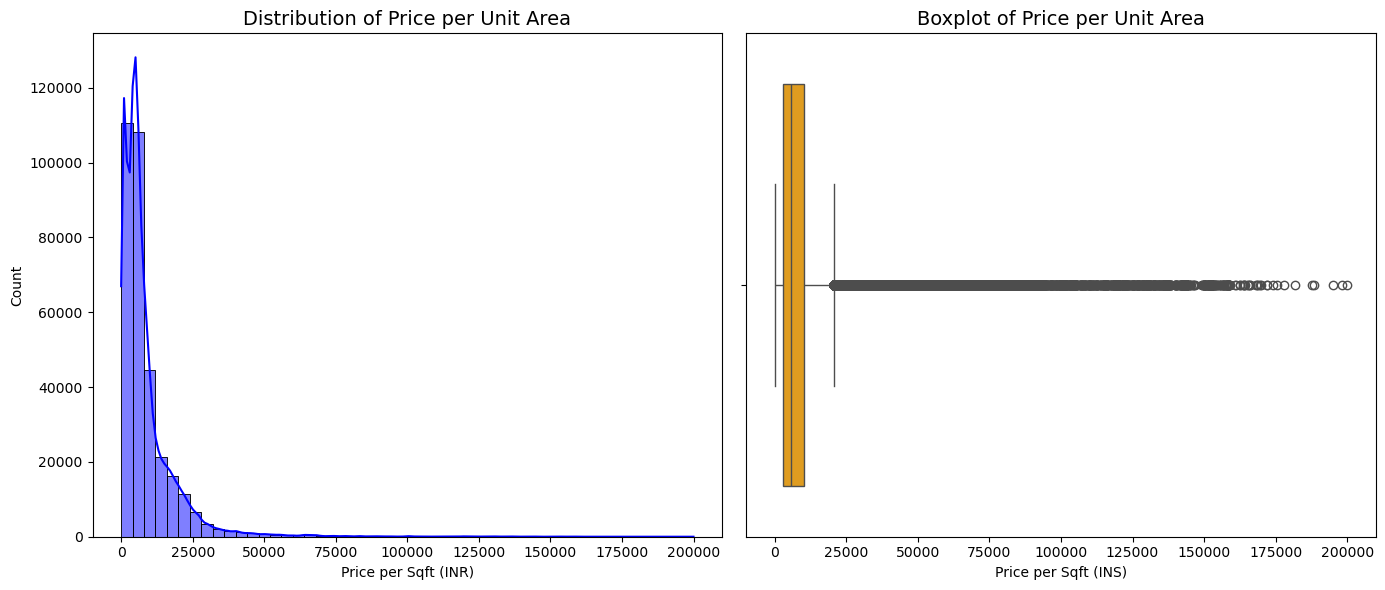

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (14, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(eda_df["Price_per_unit_area"].dropna(), bins = 50, kde = True, color = "blue")
plt.title("Distribution of Price per Unit Area", fontsize = 14)
plt.xlabel("Price per Sqft (INR)")
plt.ylabel("Count")

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x = eda_df["Price_per_unit_area"], color = "orange")
plt.title("Boxplot of Price per Unit Area", fontsize = 14)
plt.xlabel("Price per Sqft (INS)")

plt.tight_layout()
plt.show()

#### **Histogram (left)**
##### - Strong right skew : most properties are clustered in the ₹2,000 – ₹15,000 per sqft range.
##### - Very few properties are priced above ₹50,000 per sqft (rare luxury properties).
#### **Boxplot (right)**
##### - Confirms presence of extreme outliers (₹100,000 – ₹200,000 per sqft).
##### - Majority of data lies in the ₹0 – ₹25,000 per sqft range.

### **Step 4 : City-wise Price Analysis**

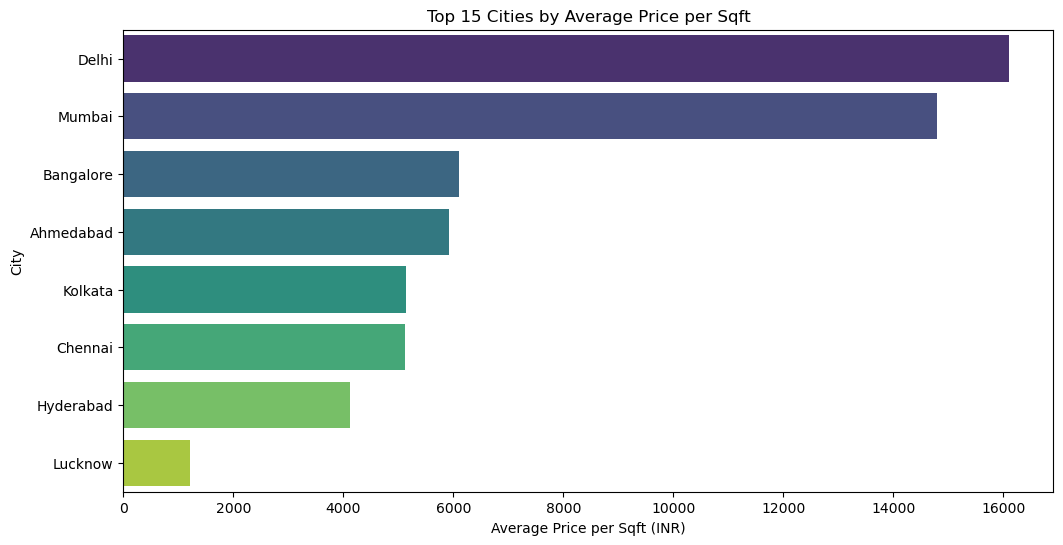

City_name
Delhi        16106.861068
Mumbai       14802.834893
Bangalore     6100.476089
Ahmedabad     5913.004100
Kolkata       5135.602324
Chennai       5129.612309
Hyderabad     4128.538589
Lucknow       1212.393858
Name: Price_per_unit_area, dtype: float64

In [40]:
# Group by city and calculate avg price per unit area
city_prices = eda_df.groupby("City_name")["Price_per_unit_area"].mean().sort_values(ascending = False)

# Plot top 15 cities by avg price per sqft
plt.figure(figsize = (12, 6))
sns.barplot(x = city_prices.head(15), y = city_prices.head(15).index, palette = "viridis")
plt.title("Top 15 Cities by Average Price per Sqft")
plt.xlabel("Average Price per Sqft (INR)")
plt.ylabel("City")

plt.show()

city_prices.head(15)

##### - Delhi (₹16,100/sqft) and Mumbai (₹14,800/sqft) are the most expensive housing markets.
##### - Bangalore, Ahmedabad, Kolkata, and Chennai (~₹5,000–6,000/sqft) are mid-range metro cities.
##### - Hyderabad (~ ₹4,100/sqft) and Lucknow (~ ₹1,200/sqft) are more affordable, showing potential growth in Tier-2 cities.

### **Step 5 : Property Type vs. Price**

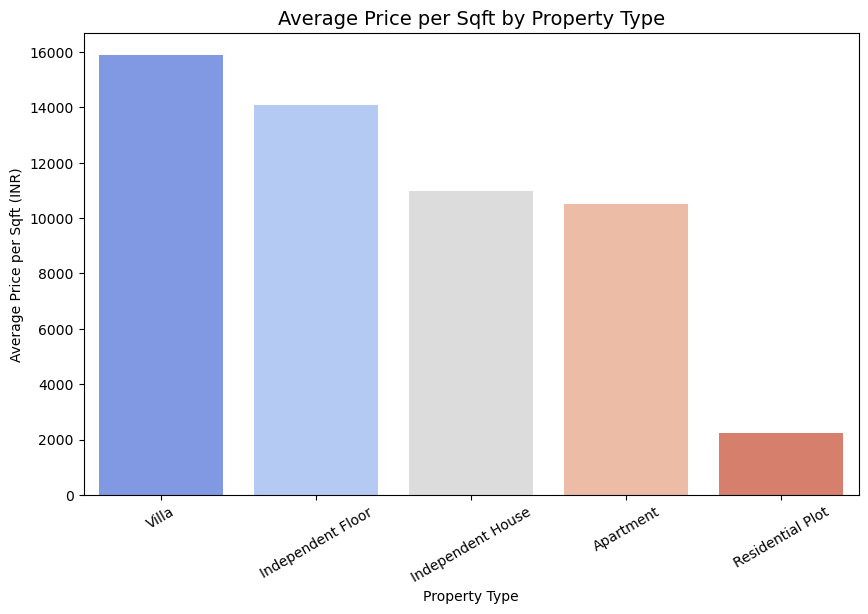

Property_type
Villa                15901.167719
Independent Floor    14103.806110
Independent House    10986.596252
Apartment            10508.992251
Residential Plot      2226.185976
Name: Price_per_unit_area, dtype: float64

In [43]:
# Group by property type and calculate avg price
type_prices = eda_df.groupby("Property_type")["Price_per_unit_area"].mean().sort_values(ascending = False)

# Plot
plt.figure(figsize = (10, 6))
sns.barplot(x = type_prices.index, y = type_prices.values, palette = "coolwarm")
plt.title("Average Price per Sqft by Property Type", fontsize = 14)
plt.ylabel("Average Price per Sqft (INR)")
plt.xlabel("Property Type")
plt.xticks(rotation = 30)
plt.show()

type_prices

##### - Villas (~ ₹15,900/sqft) and Independent Floors (~ ₹14,100/sqft) are the most expensive property types.
##### - Independent Houses (~ ₹11,000/sqft) and Apartments (~ ₹10,500/sqft) are mid-range.
##### - Residential Plots (~ ₹2,200/sqft) are the cheapest, making them more affordable for buyers.
##### **This shows that luxury properties (Villas, Floors) dominate in price, while plots remain budget-friendly.**

### **Step 6: Furnishing Type vs. Price**

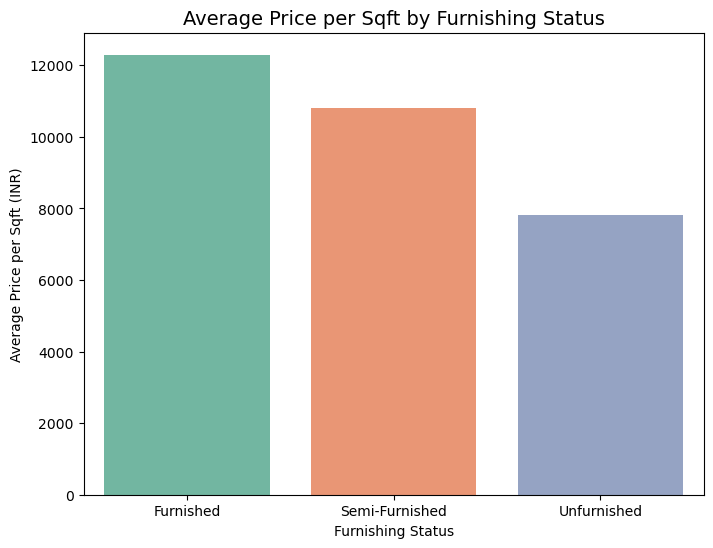

is_furnished
Furnished         12297.466190
Semi-Furnished    10805.681824
Unfurnished        7806.373944
Name: Price_per_unit_area, dtype: float64

In [46]:
# Groupby furnishing status and calculate avg price
furnish_prices = eda_df.groupby("is_furnished")["Price_per_unit_area"].mean().sort_values(ascending = False)

# Plot 
plt.figure(figsize = (8, 6))
sns.barplot(x = furnish_prices.index, y = furnish_prices.values, palette = "Set2")
plt.title("Average Price per Sqft by Furnishing Status", fontsize = 14)
plt.ylabel("Average Price per Sqft (INR)")
plt.xlabel("Furnishing Status")
plt.show()

furnish_prices

##### - Furnished properties (~₹12,300/sqft) are the most expensive, showing premium value.
##### - Semi-Furnished (~₹10,800/sqft) fall in the middle range.
##### - Unfurnished (~₹7,800/sqft) are the cheapest, attracting budget buyers.
##### **This shows that buyers are willing to pay extra for ready-to-move, fully furnished homes.**

### **Step 7 : Property Status vs. Price**

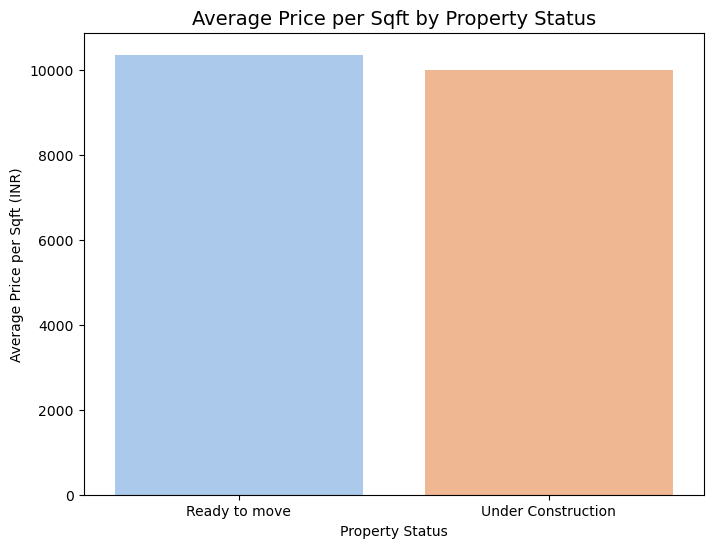

Property_status
Ready to move         10353.222686
Under Construction     9998.848183
Name: Price_per_unit_area, dtype: float64

In [55]:
# Group by property status and calculate avg price
status_prices = eda_df.groupby("Property_status")["Price_per_unit_area"].mean().sort_values(ascending = False)

# Plot
plt.figure(figsize = (8, 6))
sns.barplot(x = status_prices.index, y = status_prices.values, palette = "pastel")
plt.title("Average Price per Sqft by Property Status", fontsize = 14)
plt.ylabel("Average Price per Sqft (INR)")
plt.xlabel("Property Status")
plt.show()

status_prices

##### - Ready to Move properties (~ ₹10,350/sqft) are slightly more expensive than Under Construction (~ ₹10,000/sqft).
##### - Buyers pay a premium for immediate availability and lower risk compared to under-construction projects.
##### - Price difference is not huge, meaning under-construction projects are competitive but still slightly cheaper.

### **Step 8 : Number of BHK vs. Price**

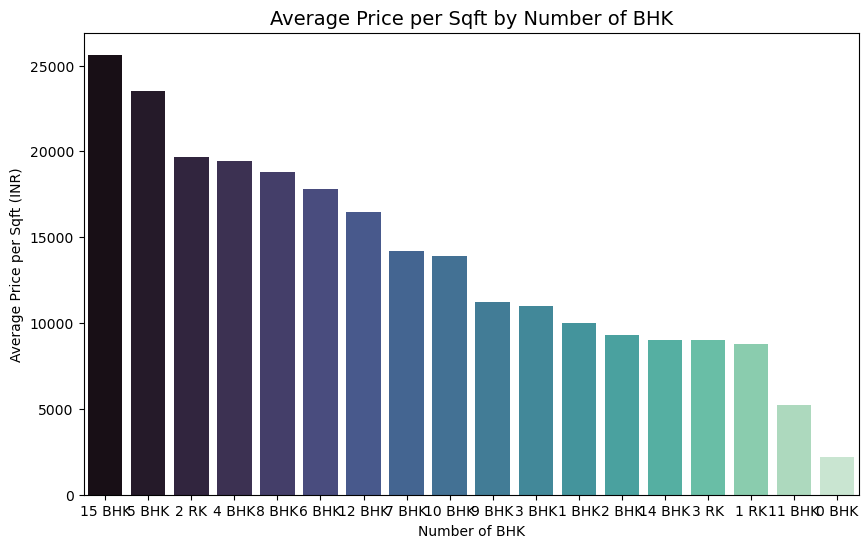

No_of_BHK
15 BHK    25628.533333
5 BHK     23531.123471
2 RK      19676.000000
4 BHK     19465.124484
8 BHK     18774.707031
6 BHK     17826.032787
12 BHK    16453.000000
7 BHK     14197.264331
10 BHK    13895.865443
9 BHK     11201.981366
3 BHK     10982.195078
1 BHK     10030.765738
2 BHK      9302.387327
14 BHK     9000.000000
3 RK       8999.000000
1 RK       8796.878560
11 BHK     5245.071429
0 BHK      2226.185976
Name: Price_per_unit_area, dtype: float64

In [62]:
# Group by number of BHK and calculate avg price
bhk_prices = eda_df.groupby("No_of_BHK")["Price_per_unit_area"].mean().sort_values(ascending = False)

# Plot 
plt.figure(figsize = (10, 6))
sns.barplot(x = bhk_prices.index, y = bhk_prices.values, palette = "mako")
plt.title("Average Price per Sqft by Number of BHK", fontsize = 14)
plt.ylabel("Average Price per Sqft (INR)")
plt.xlabel("Number of BHK")
plt.show()

bhk_prices

##### - Luxury properties (15BHK, 5BHK, 8BHK, etc.) have the highest average prices per sqft (₹18k–₹25k), showing they are premium/luxury homes.
##### - Mid-sized homes (2BHK, 3BHK, 4BHK) fall in the range of ₹9k–₹11k per sqft, which is the most common segment for urban buyers.
##### - Small units (1RK, 1BHK, 0BHK) are cheaper (~₹8k or less), reflecting affordability but lower demand in premium markets.
##### **This shows a clear pattern: larger luxury BHK homes demand higher price per sqft, while 2BHK–3BHK remain the mainstream affordable segment.**

### **Step 9 : Locality-wise Price Analysis**

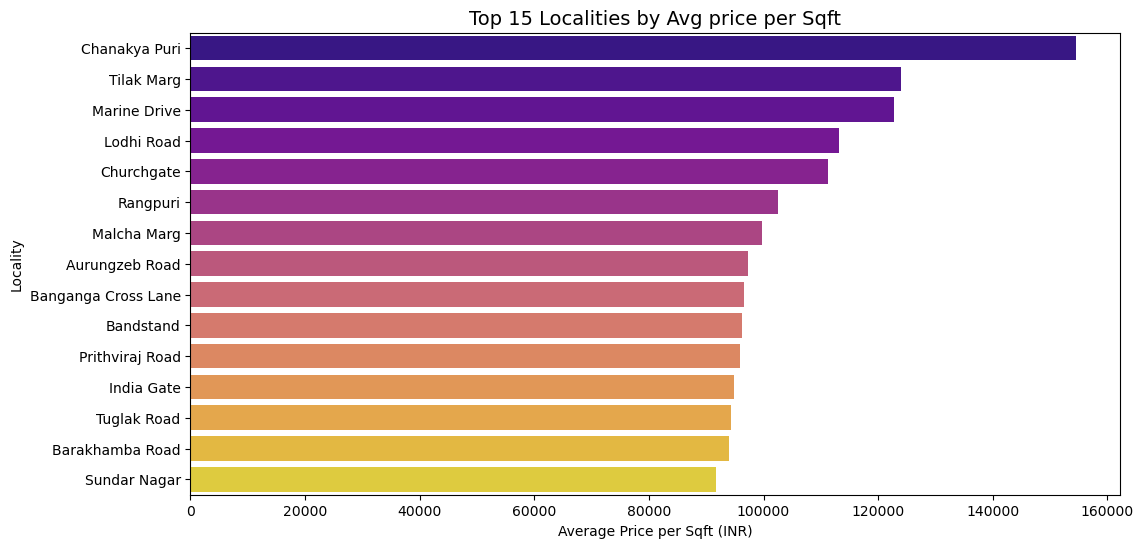

Locality_Name
Chanakya Puri          154545.000000
Tilak Marg             123929.000000
Marine Drive           122692.882353
Lodhi Road             113228.750000
Churchgate             111224.687500
Rangpuri               102500.000000
Malcha Marg             99821.093750
Aurungzeb Road          97346.693548
Banganga Cross Lane     96666.000000
Bandstand               96296.000000
Prithviraj Road         95899.131579
India Gate              94898.571429
Tuglak Road             94381.533333
Barakhamba Road         93892.800000
Sundar Nagar            91770.750000
Name: Price_per_unit_area, dtype: float64

In [66]:
# Group by Locality and calculate avg price
locality_prices = eda_df.groupby("Locality_Name")["Price_per_unit_area"].mean().sort_values(ascending = False)

# Plot top 15 localities
plt.figure(figsize = (12, 6))
sns.barplot(x = locality_prices.head(15).values, y = locality_prices.head(15).index, palette = "plasma")
plt.title("Top 15 Localities by Avg price per Sqft", fontsize = 14)
plt.xlabel("Average Price per Sqft (INR)")
plt.ylabel("Locality")
plt.show()

locality_prices.head(15)

##### - Ultra-premium areas in Delhi (Chanakya Puri, Tilak Marg, Lodhi Road) and Mumbai (Marine Drive, Churchgate, Bandstand) dominate, with prices above ₹1,00,000 per sqft.
##### - These localities are political, business, or coastal hubs, which explains the extreme real estate value.
##### - Other elite zones like Aurangzeb Road, Prithviraj Road, and Barakhamba Road also feature as high-priced markets, highlighting the luxury housing clusters.
##### **This proves that location is the strongest driver of housing prices.**

### **Step 10 : Correlation Heatmap**

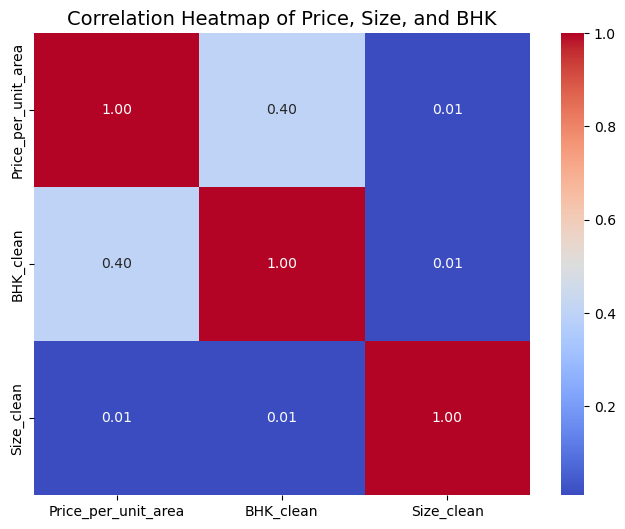

,Price_per_unit_area,BHK_clean,Size_clean
Price_per_unit_area,1.000000,0.402671,0.009114
BHK_clean,0.402671,1.000000,0.012292
Size_clean,0.009114,0.012292,1.000000


In [74]:
# Clean No_of_BHK (extract numbers)
eda_df["BHK_clean"] = eda_df["No_of_BHK"].astype(str).str.extract(r'(\d+)').astype(float)

# Clean Size (extract numbers)
eda_df["Size_clean"] = eda_df["Size"].astype(str).str.replace(",", "").str.extract(r'(\d+)').astype(float)

# Select numeric columns
num_cols = eda_df[["Price_per_unit_area", "BHK_clean", "Size_clean"]]

# Compute correlation matrix
corr = num_cols.corr()

# Plot heatmap
plt.figure(figsize = (8, 6))
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f", cbar = True)
plt.title("Correlation Heatmap of Price, Size, and BHK", fontsize = 14)
plt.show()

corr

##### - Price_per_unit_area : BHK_clean (0.40) -> moderate positive correlation -> generally, more BHK homes tend to have higher price per sqft, reflecting premium housing.
##### - Price_per_unit_area : Size_clean (0.01) -> almost no correlation -> larger homes don’t necessarily cost more per sqft (luxury location matters more than size).
##### - BHK_clean : Size_clean (0.01) -> very weak -> shows that number of bedrooms isn’t strongly tied to size in sqft (likely due to dataset inconsistencies or varying layouts).

## **ML - Machine Learning : Model Building**

### **Step 1: Train-Test Split & Preprocessing**

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Separate categorical and numeric features
categorical_features = ["Property_type", "Property_status", "is_furnished"]
numeric_features = ["is_RERA_registered", "is_ready_to_move", "is_commercial_Listing"]

# Preprocessing:
# - OneHotEncode categorical
# - StandardScale numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (265676, 6) Test shape: (66420, 6)


#### **What this does**
##### - Splits data into train (80%) and test (20%).
##### - Defines preprocessing:
##### - OneHotEncoder → converts categories (like "Apartment", "Under Construction") into machine-readable form.
##### - StandardScaler → scales numeric boolean-like values (0/1).

### **Step 2: Model Training & Evaluation**

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Function to evaluate model performance
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"📊 {name} Performance:")
    print(f"   MAE  : {mae:.2f}")
    print(f"   RMSE : {rmse:.2f}")
    print(f"   R2 : {r2:.4f}")
    print("-"*40)
    return mae, rmse, r2

# -----------------
# 1. Linear Regression
# -----------------
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
evaluate_model("Linear Regression", lr_pipeline, X_test, y_test)

# -----------------
# 2. Random Forest Regressor
# -----------------
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
evaluate_model("Random Forest", rf_pipeline, X_test, y_test)

📊 Linear Regression Performance:
   MAE  : 5384.51
   RMSE : 9860.18
   R2 : 0.1723
----------------------------------------
📊 Random Forest Performance:
   MAE  : 5198.22
   RMSE : 9479.58
   R2 : 0.2350
----------------------------------------


(5198.224860578742, 9479.57507415268, 0.23498446934967165)

#### **What you’ll get**
##### - MAE (Mean Absolute Error) → average price prediction error in INR.
##### - RMSE (Root Mean Square Error) → penalizes big mistakes.
##### - R2 Score → explains how much variance is captured by the model (closer to 1 is better).
##### - A comparison of Linear Regression vs Random Forest.

### **Step 3: Save Trained Models**

In [88]:
import joblib

# Save the Random Forest model (best performer usually)
joblib.dump(rf_pipeline, "estatex_price_model_rf.pkl")

# Save the Linear Regression model as well (baseline)
joblib.dump(lr_pipeline, "estatex_price_model_lr.pkl")

print("Models saved successfully as 'estatex_price_model_rf.pkl' and 'estatex_price_model_lr.pkl'")

Models saved successfully as 'estatex_price_model_rf.pkl' and 'estatex_price_model_lr.pkl'


#### **What this does**
##### - Stores trained models as .pkl files.
##### - Later, you can load them back without retraining:

In [91]:
# Load model later
rf_model = joblib.load("estatex_price_model_rf.pkl")

# Example prediction (using a single sample from test set)
sample = X_test.iloc[0:1]
pred_price = rf_model.predict(sample)
print("Predicted Price per unit area:", pred_price)

Predicted Price per unit area: [11445.52671587]


##### **We tested two models: Linear Regression as a baseline and Random Forest for better accuracy. Random Forest performed better with lower error and higher R², but since only limited features were used, accuracy is still low. Future improvement includes adding more location and property details.**